
# Practical Probability & Statistics for Computer Science

This notebook focuses on the probability and statistics concepts that appear most often in:

- data science and machine learning;
- anomaly detection;
- A/B testing;
- recommendation and ranking systems;
- forecasting;
- classification;
- experimentation;
- performance analysis.

It intentionally skips elementary probability exercises and emphasizes **terminology, interpretation, assumptions, and practical implications**.

## Learning goals

After completing this notebook, I should be able to explain and use:

- distributions, parameters, samples, and estimators;
- expectation, variance, covariance, and correlation;
- z-scores, percentiles, and robust scaling;
- common distributions used in computer science;
- likelihood, probability, and Bayes' rule;
- the law of large numbers and central limit theorem;
- sampling distributions, standard error, and confidence intervals;
- null hypotheses, p-values, significance, effect size, and statistical power;
- false positives, false negatives, and multiple testing;
- probability calibration, log loss, and Brier score;
- practical warnings such as correlation vs causation and data leakage.

> Note: People sometimes say “p-score,” but the standard statistical term is usually **p-value**. In machine learning, “probability score” may instead mean a model's predicted probability.



## 1. Core vocabulary

### Population

The complete set of items or outcomes we care about.

Example: all transactions made by users of an application.

### Sample

A subset observed from the population.

Example: transactions recorded during one week.

### Parameter

A fixed but usually unknown population quantity.

Examples:

- population mean: $\mu$
- population variance: $\sigma^2$
- true conversion rate: $p$

### Statistic

A quantity calculated from a sample.

Examples:

- sample mean: $\bar{x}$
- sample variance: $s^2$
- observed conversion rate: $\hat{p}$

### Estimator and estimate

An **estimator** is a rule for estimating a parameter.

$$
\hat{\theta} = g(X_1,\ldots,X_n)
$$

The numerical result obtained from one sample is an **estimate**.

### Bias

An estimator is biased if its average estimate systematically differs from the true parameter.

$$
\operatorname{Bias}(\hat{\theta})
=
E[\hat{\theta}] - \theta
$$

### Consistency

An estimator is consistent if it approaches the true parameter as sample size increases.


In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# A population with an unknown-to-the-analyst mean
population = rng.normal(loc=100, scale=15, size=100_000)

sample = rng.choice(population, size=100, replace=False)

print("Population mean:", population.mean())
print("Sample mean:", sample.mean())


Population mean: 99.93650604581617
Sample mean: 101.41889144784687



## 2. Random variables and distributions

A **random variable** maps uncertain outcomes to numbers.

A **probability distribution** describes which values a random variable can take and how probability is allocated among those values.

### Discrete distribution

Used when values are countable.

Examples:

- number of requests in one second;
- number of failed tests;
- whether a user clicks.

A discrete distribution is described by a **probability mass function (PMF)**:

$$
P(X=x)
$$

### Continuous distribution

Used when values can vary continuously.

Examples:

- response time;
- file size;
- temperature;
- model error.

A continuous distribution is described by a **probability density function (PDF)**.

Important:

$$
P(X=x)=0
$$

for a single exact value of a continuous random variable. Probability is obtained from an interval:

$$
P(a<X<b)
=
\int_a^b f(x)\,dx
$$

### Cumulative distribution function

The **CDF** gives the probability that a variable is at most a given value:

$$
F(x)=P(X\le x)
$$

CDFs are useful for percentiles, thresholds, and tail probabilities.



## 3. Expected value and variance

### Expected value

The expected value is the probability-weighted long-run average.

Discrete case:

$$
E[X] = \sum_x xP(X=x)
$$

Continuous case:

$$
E[X] = \int_{-\infty}^{\infty} x f(x)\,dx
$$

Expected value is not necessarily a possible individual outcome.

### Variance

Variance measures average squared distance from the mean:

$$
\operatorname{Var}(X)
=
E[(X-\mu)^2]
$$

Equivalent form:

$$
\operatorname{Var}(X)
=
E[X^2] - E[X]^2
$$

### Standard deviation

$$
\sigma = \sqrt{\operatorname{Var}(X)}
$$

Standard deviation has the same unit as the original variable; variance has squared units.

### Practical implication

- mean describes the center;
- standard deviation describes typical spread;
- a large standard deviation means observations are less concentrated around the mean.


In [4]:

values = np.array([0, 1, 2])
probabilities = np.array([0.2, 0.5, 0.3])

expected_value = np.sum(values * probabilities)
variance = np.sum((values - expected_value) ** 2 * probabilities)
std_dev = np.sqrt(variance)

expected_value, variance, std_dev


(np.float64(1.1), np.float64(0.49), np.float64(0.7))


## 4. Z-scores and standardization

A **z-score** measures how many standard deviations a value is above or below the mean:

$$
z = \frac{x-\mu}{\sigma}
$$

Interpretation:

- $z=0$: equal to the mean;
- $z=1$: one standard deviation above the mean;
- $z=-2$: two standard deviations below the mean.

### Uses in computer science

- feature scaling before machine learning;
- anomaly detection;
- comparing values measured on different scales;
- identifying unusually high or low observations.

### Important limitations

A z-score is meaningful as a standardized distance even when data is not normal. However, interpreting $z=2$ as a specific tail probability assumes a normal or approximately normal distribution.

Z-scores are sensitive to outliers because both mean and standard deviation are sensitive to outliers.


In [5]:

latencies = np.array([105, 110, 98, 102, 115, 108, 100, 103, 109, 400])

mean_latency = latencies.mean()
std_latency = latencies.std(ddof=0)

z_scores = (latencies - mean_latency) / std_latency

pd.DataFrame({
    "latency": latencies,
    "z_score": z_scores
})


,latency,z_score
0,105,-0.339114
1,110,-0.282595
2,98,-0.418241
3,102,-0.373025
4,115,-0.226076
5,108,-0.305203
6,100,-0.395633
7,103,-0.361722
8,109,-0.293899
9,400,2.995507



## 5. Robust alternatives: median, IQR, and robust z-score

The mean and standard deviation may be distorted by extreme observations.

### Median

The middle value after sorting. It is more resistant to outliers than the mean.

### Interquartile range

$$
IQR = Q_3-Q_1
$$

It measures the spread of the middle 50% of the data.

A common outlier rule marks values outside:

$$
[Q_1-1.5IQR,\;Q_3+1.5IQR]
$$

### Median absolute deviation

$$
MAD = \operatorname{median}(|x_i-\operatorname{median}(x)|)
$$

A robust z-like score can be computed as:

$$
z_{\text{robust}}
=
0.6745
\frac{x-\operatorname{median}(x)}{MAD}
$$

### Practical implication

Use robust measures when the data is skewed or contains extreme outliers.


In [6]:

median_latency = np.median(latencies)
mad = np.median(np.abs(latencies - median_latency))

robust_z = 0.6745 * (latencies - median_latency) / mad

pd.DataFrame({
    "latency": latencies,
    "ordinary_z": z_scores,
    "robust_z": robust_z
})


,latency,ordinary_z,robust_z
0,105,-0.339114,-0.252937
1,110,-0.282595,0.590187
2,98,-0.418241,-1.433312
3,102,-0.373025,-0.758813
4,115,-0.226076,1.433312
5,108,-0.305203,0.252937
6,100,-0.395633,-1.096062
7,103,-0.361722,-0.590187
8,109,-0.293899,0.421563
9,400,2.995507,49.491437



## 6. Percentiles and quantiles

The $q$-quantile is a value below which a fraction $q$ of observations fall.

Examples:

- 0.25 quantile = first quartile $Q_1$;
- 0.50 quantile = median;
- 0.95 quantile = 95th percentile.

### Common CS uses

- p95 or p99 API latency;
- top 1% of users by activity;
- anomaly thresholds;
- service-level objectives.

### Important implication

Average latency can hide bad tail performance. A system may have a low mean latency but a very high p99 latency.


In [7]:

server_latency = rng.lognormal(mean=4.5, sigma=0.6, size=10_000)

summary = {
    "mean": server_latency.mean(),
    "median": np.median(server_latency),
    "p95": np.percentile(server_latency, 95),
    "p99": np.percentile(server_latency, 99),
}

summary


{'mean': np.float64(107.82897058585588),
 'median': np.float64(89.38932732563916),
 'p95': np.float64(245.6017771130249),
 'p99': np.float64(379.8988286446383)}


## 7. Shape of a distribution

### Symmetry

A symmetric distribution has similar shape on both sides of its center.

### Skewness

Skewness measures asymmetry.

- positive/right skew: long right tail;
- negative/left skew: long left tail.

Right-skewed examples:

- income;
- request latency;
- file size.

For right-skewed data, the mean is often larger than the median.

### Kurtosis

Kurtosis is related to tail heaviness and the tendency to produce extreme observations.

High kurtosis does not merely mean a “tall peak”; the more important interpretation is heavier tails and greater outlier risk.

### Modality

- unimodal: one major peak;
- bimodal: two major peaks;
- multimodal: multiple peaks.

Multiple modes may indicate hidden subgroups.


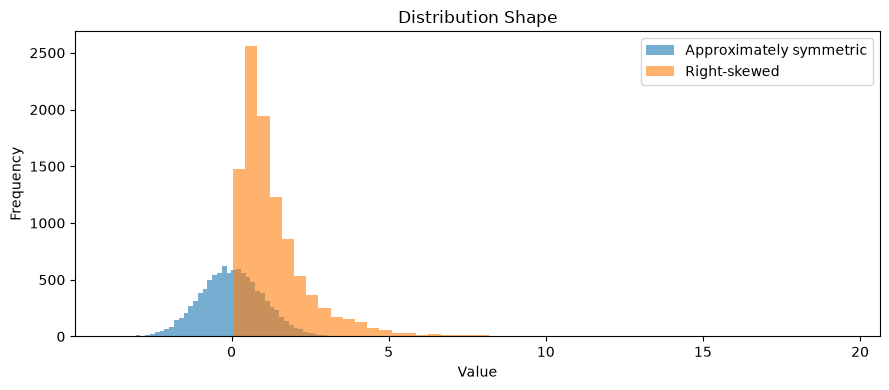

In [8]:

normal_data = rng.normal(0, 1, 10_000)
skewed_data = rng.lognormal(0, 0.8, 10_000)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(normal_data, bins=50, alpha=0.6, label="Approximately symmetric")
ax.hist(skewed_data, bins=50, alpha=0.6, label="Right-skewed")
ax.set_title("Distribution Shape")
ax.set_xlabel("Value")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()



## 8. Common distributions used in CS

### Bernoulli distribution

Models one binary outcome:

$$
X\in\{0,1\}
$$

$$
P(X=1)=p,\qquad P(X=0)=1-p
$$

Examples:

- click/no click;
- fraud/not fraud;
- success/failure.

### Binomial distribution

Counts successes in $n$ independent Bernoulli trials with constant success probability $p$:

$$
X\sim\operatorname{Binomial}(n,p)
$$

$$
E[X]=np
$$

$$
\operatorname{Var}(X)=np(1-p)
$$

Example: number of users who click among 100 independently exposed users.

### Poisson distribution

Models counts occurring in a fixed interval when events occur independently at an approximately constant average rate:

$$
X\sim\operatorname{Poisson}(\lambda)
$$

$$
E[X]=\operatorname{Var}(X)=\lambda
$$

Examples:

- requests per second;
- errors per hour;
- arrivals per minute.

### Normal distribution

A symmetric bell-shaped distribution described by mean and variance:

$$
X\sim N(\mu,\sigma^2)
$$

It is important because many aggregated quantities become approximately normal through the central limit theorem.

### Exponential distribution

Models waiting time between Poisson events:

$$
X\sim\operatorname{Exponential}(\lambda)
$$

It is memoryless:

$$
P(X>s+t\mid X>s)=P(X>t)
$$

Examples:

- time until next request under a simple Poisson model;
- component lifetime under a constant failure rate assumption.

### Uniform distribution

Every value in a range has equal density.

Often used for:

- random initialization;
- simulation;
- randomized algorithms.


In [9]:

from scipy.stats import binom, poisson, norm, expon

print("P(exactly 5 clicks among 20 users, p=0.2):", binom.pmf(5, 20, 0.2))
print("P(at most 3 errors when lambda=2):", poisson.cdf(3, mu=2))
print("P(Z > 1.96):", norm.sf(1.96))
print("P(waiting more than 5 units, lambda=0.2):", expon.sf(5, scale=1/0.2))


P(exactly 5 clicks among 20 users, p=0.2): 0.17455952155688056
P(at most 3 errors when lambda=2): 0.857123460498547
P(Z > 1.96): 0.024997895148220435
P(waiting more than 5 units, lambda=0.2): 0.36787944117144233



## 9. Probability versus likelihood

These words are related but not interchangeable.

### Probability

Treats model parameters as fixed and asks about possible data:

$$
P(\text{data}\mid\theta)
$$

Example:

> If the coin's head probability is $p=0.7$, what is the probability of observing 8 heads in 10 flips?

### Likelihood

Treats observed data as fixed and compares possible parameter values:

$$
L(\theta\mid\text{data})
\propto
P(\text{data}\mid\theta)
$$

Example:

> Given 8 heads in 10 flips, which value of $p$ makes this observation most plausible?

### Maximum likelihood estimation

The maximum likelihood estimator selects the parameter that maximizes the likelihood:

$$
\hat{\theta}_{MLE}
=
\arg\max_\theta L(\theta\mid \text{data})
$$

For Bernoulli data, the MLE of $p$ is the observed success proportion.


In [10]:

# 8 heads in 10 flips: inspect likelihood for candidate p values

p_grid = np.linspace(0.01, 0.99, 99)
likelihood = p_grid**8 * (1 - p_grid)**2

best_p = p_grid[np.argmax(likelihood)]
best_p


np.float64(0.8)


## 10. Conditional probability and Bayes' rule

Conditional probability:

$$
P(A\mid B)
=
\frac{P(A\cap B)}{P(B)}
$$

Bayes' rule reverses the conditioning direction:

$$
P(A\mid B)
=
\frac{P(B\mid A)P(A)}{P(B)}
$$

### Terminology

- **prior**: $P(A)$, belief before seeing evidence;
- **likelihood**: $P(B\mid A)$, compatibility of evidence with the hypothesis;
- **posterior**: $P(A\mid B)$, updated belief after evidence;
- **evidence**: $P(B)$, total probability of the observed evidence.

### Practical implication: base-rate neglect

A highly accurate test can still produce many false positives if the condition is rare.

This matters in:

- fraud detection;
- intrusion detection;
- medical testing;
- spam filtering.


In [11]:

# Example: rare event detection

prevalence = 0.01       # P(fraud)
sensitivity = 0.95      # P(flagged | fraud)
false_positive_rate = 0.05  # P(flagged | not fraud)

p_flagged = (
    sensitivity * prevalence
    + false_positive_rate * (1 - prevalence)
)

p_fraud_given_flagged = sensitivity * prevalence / p_flagged

p_fraud_given_flagged


0.16101694915254236


## 11. Independence, dependence, covariance, and correlation

### Independence

$X$ and $Y$ are independent if knowing one gives no information about the other.

Independence implies zero covariance, but zero covariance does not necessarily imply independence.

### Covariance

$$
\operatorname{Cov}(X,Y)
=
E[(X-\mu_X)(Y-\mu_Y)]
$$

- positive: variables tend to move together;
- negative: one tends to increase when the other decreases;
- near zero: little linear co-movement.

Covariance depends on units.

### Pearson correlation

$$
\rho_{X,Y}
=
\frac{\operatorname{Cov}(X,Y)}
{\sigma_X\sigma_Y}
$$

Correlation ranges from $-1$ to $1$ and measures linear association.

### Important warnings

- correlation does not imply causation;
- correlation can miss nonlinear relationships;
- outliers can strongly affect correlation;
- a confounding variable can create a misleading relationship.


In [14]:

x = rng.uniform(-3, 3, 1000)
y = x**2 + rng.normal(0, 0.3, 1000)

correlation = np.corrcoef(x, y)[0, 1]
correlation


np.float64(-0.013789021842828467)

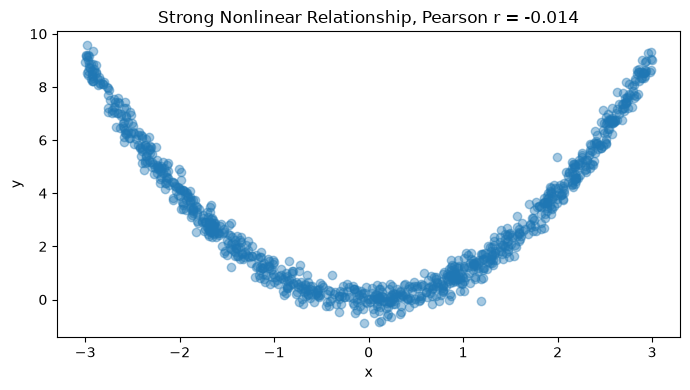

In [15]:

plt.figure(figsize=(7, 4))
plt.scatter(x, y, alpha=0.4)
plt.title(f"Strong Nonlinear Relationship, Pearson r = {correlation:.3f}")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()



## 12. Law of large numbers

The **law of large numbers (LLN)** says that as the number of independent observations grows, the sample average tends to approach the expected value.

$$
\bar{X}_n
\to
E[X]
$$

### Practical implication

More observations usually stabilize estimates, but:

- more data does not fix systematic bias;
- dependent samples can violate assumptions;
- a nonrepresentative sample can converge to the wrong target.


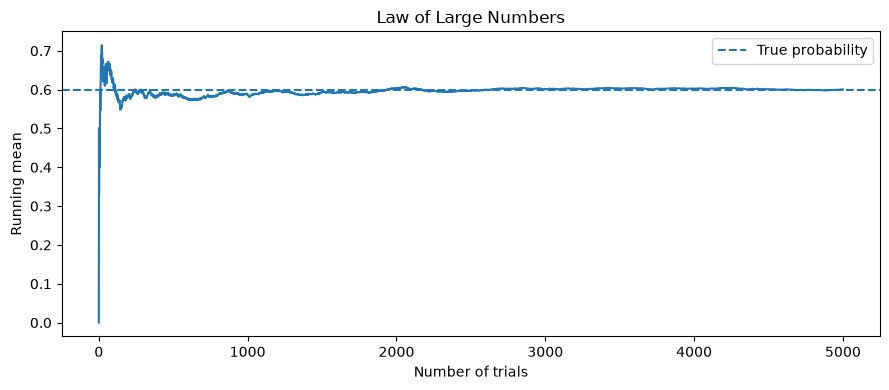

In [16]:

coin_flips = rng.binomial(1, 0.6, size=5000)
running_mean = np.cumsum(coin_flips) / np.arange(1, len(coin_flips) + 1)

plt.figure(figsize=(9, 4))
plt.plot(running_mean)
plt.axhline(0.6, linestyle="--", label="True probability")
plt.title("Law of Large Numbers")
plt.xlabel("Number of trials")
plt.ylabel("Running mean")
plt.legend()
plt.tight_layout()
plt.show()



## 13. Central limit theorem

The **central limit theorem (CLT)** states that under suitable conditions, the distribution of sample means becomes approximately normal as sample size increases, even if the original population is not normal.

For independent identically distributed observations with finite variance:

$$
\frac{\bar{X}-\mu}{\sigma/\sqrt{n}}
$$

becomes approximately standard normal for sufficiently large $n$.

### Practical implications

The CLT supports:

- confidence intervals;
- hypothesis tests;
- normal approximations;
- uncertainty estimates for averages.

### Important distinction

The CLT does **not** say that the original data becomes normal. It says that the **sampling distribution of the mean** becomes approximately normal.


In [ ]:

# Original population is strongly right-skewed
population = rng.exponential(scale=2.0, size=200_000)

sample_means = np.array([
    rng.choice(population, size=40, replace=True).mean()
    for _ in range(5000)
])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(population[:10_000], bins=50)
axes[0].set_title("Original Exponential Data")

axes[1].hist(sample_means, bins=50)
axes[1].set_title("Sampling Distribution of the Mean")

plt.tight_layout()
plt.show()



## 14. Sampling distributions and standard error

A **sampling distribution** is the distribution of a statistic across repeated samples.

For the sample mean:

$$
E[\bar{X}]=\mu
$$

and:

$$
SE(\bar{X})
=
\frac{\sigma}{\sqrt{n}}
$$

When population standard deviation is unknown:

$$
SE(\bar{X})
\approx
\frac{s}{\sqrt{n}}
$$

### Standard deviation versus standard error

- standard deviation: spread of individual observations;
- standard error: uncertainty in an estimated statistic.

As sample size grows:

$$
SE \propto \frac{1}{\sqrt{n}}
$$

To halve the standard error, approximately four times as much data is needed.


In [ ]:

sample_sizes = np.array([25, 100, 400, 1600])
sigma = 20

standard_errors = sigma / np.sqrt(sample_sizes)

pd.DataFrame({
    "sample_size": sample_sizes,
    "standard_error": standard_errors
})



## 15. Confidence intervals

A confidence interval gives a range produced by a procedure that captures the true parameter at a specified long-run rate.

Approximate 95% confidence interval for a mean:

$$
\bar{x}
\pm
1.96\cdot SE
$$

### Correct interpretation

A 95% confidence procedure would contain the true parameter in about 95% of repeated samples.

After one interval is calculated, the parameter is fixed; the interval either contains it or does not.

### Common mistake

It is not strictly correct in frequentist statistics to say:

> There is a 95% probability that the fixed parameter lies in this already calculated interval.

That Bayesian interpretation requires a posterior distribution.


In [ ]:

sample = rng.normal(loc=50, scale=10, size=100)

sample_mean = sample.mean()
sample_se = sample.std(ddof=1) / np.sqrt(len(sample))

ci_low = sample_mean - 1.96 * sample_se
ci_high = sample_mean + 1.96 * sample_se

sample_mean, (ci_low, ci_high)



## 16. Hypothesis testing vocabulary

### Null hypothesis

The default claim being tested.

$$
H_0
$$

Example:

$$
H_0:\mu_A=\mu_B
$$

### Alternative hypothesis

The competing claim:

$$
H_1:\mu_A\ne\mu_B
$$

### Test statistic

A standardized measure of how far the observed result is from what $H_0$ predicts.

### P-value

The p-value is:

> the probability, assuming the null hypothesis is true, of obtaining a result at least as extreme as the observed result.

It is **not**:

- the probability that the null hypothesis is true;
- the probability that the result occurred by chance;
- the size or importance of an effect.

### Significance level

A threshold chosen before analysis, commonly:

$$
\alpha=0.05
$$

If:

$$
p<\alpha
$$

the result is called statistically significant.

Statistical significance does not guarantee practical importance.


In [ ]:

from scipy.stats import ttest_ind

group_a = rng.normal(loc=100, scale=15, size=100)
group_b = rng.normal(loc=105, scale=15, size=100)

t_stat, p_value = ttest_ind(group_a, group_b, equal_var=False)

print("t statistic:", t_stat)
print("p-value:", p_value)



## 17. Type I error, Type II error, and power

### Type I error

Rejecting a true null hypothesis: false positive.

Probability:

$$
P(\text{Type I error})=\alpha
$$

### Type II error

Failing to reject a false null hypothesis: false negative.

Probability:

$$
\beta
$$

### Statistical power

Probability of detecting a real effect:

$$
\text{Power}=1-\beta
$$

Power generally increases with:

- larger sample size;
- larger true effect;
- lower noise;
- higher significance threshold;
- better experimental design.

### Practical implication

A non-significant result does not necessarily prove that no effect exists. The study may simply have low power.



## 18. Effect size

A p-value describes evidence against $H_0$, not the magnitude of the effect.

An **effect size** measures practical magnitude.

### Difference in means

$$
\bar{x}_A-\bar{x}_B
$$

### Relative lift

$$
\frac{\text{new}-\text{old}}{\text{old}}
$$

### Cohen's $d$

$$
d=
\frac{\bar{x}_A-\bar{x}_B}
{s_{\text{pooled}}}
$$

### Practical implication

Always report an effect estimate and uncertainty, not only a p-value.


In [ ]:

mean_a = group_a.mean()
mean_b = group_b.mean()

pooled_std = np.sqrt(
    ((len(group_a) - 1) * group_a.var(ddof=1)
     + (len(group_b) - 1) * group_b.var(ddof=1))
    / (len(group_a) + len(group_b) - 2)
)

cohens_d = (mean_b - mean_a) / pooled_std

{
    "mean_difference": mean_b - mean_a,
    "cohens_d": cohens_d
}



## 19. Multiple testing

When many hypotheses are tested, false positives accumulate.

If 20 independent true null hypotheses are each tested at $\alpha=0.05$, the chance of at least one false positive is:

$$
1-(1-0.05)^{20}
$$

This is much larger than 5%.

### Common corrections

#### Bonferroni correction

Use:

$$
\alpha_{\text{adjusted}}
=
\frac{\alpha}{m}
$$

where $m$ is the number of tests.

#### False discovery rate

Methods such as Benjamini-Hochberg control the expected proportion of false discoveries among rejected hypotheses.

### Practical implication

Repeatedly trying metrics, segments, features, or model variants until something becomes significant is a form of p-hacking.


In [ ]:

m = 20
alpha = 0.05

probability_at_least_one_false_positive = 1 - (1 - alpha) ** m
probability_at_least_one_false_positive



## 20. Predicted probabilities and calibration

A classifier may output a probability score such as:

$$
\hat{P}(Y=1\mid X)=0.8
$$

A model is **well calibrated** if, among cases assigned probability 0.8, roughly 80% are actually positive.

### Accuracy is not enough

Two models can have the same classification accuracy but very different probability quality.

### Brier score

For binary outcomes:

$$
\text{Brier}
=
\frac{1}{n}
\sum_{i=1}^n
(p_i-y_i)^2
$$

Lower is better.

### Log loss

$$
-\frac{1}{n}
\sum_{i=1}^n
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

Log loss heavily penalizes confident wrong predictions.

### Practical implication

Use probability metrics when decisions depend on confidence, ranking, risk, or expected cost.


In [ ]:

from sklearn.metrics import brier_score_loss, log_loss

y_true = np.array([1, 0, 1, 1, 0, 0])
predicted_probabilities = np.array([0.9, 0.2, 0.7, 0.6, 0.3, 0.1])

print("Brier score:", brier_score_loss(y_true, predicted_probabilities))
print("Log loss:", log_loss(y_true, predicted_probabilities))



## 21. Expected loss and decision thresholds

A probability prediction does not by itself determine the final decision.

The decision threshold should depend on the costs of errors.

Suppose:

- false negative cost = 100;
- false positive cost = 10.

Then missing a positive case is much more expensive than raising a false alarm.

### Expected cost idea

Choose the action with the smaller expected loss.

This connects probability to:

- fraud review;
- medical alerts;
- spam detection;
- credit risk;
- security monitoring.

A threshold of 0.5 is not automatically optimal.



## 22. Statistical assumptions and failure modes

### Independence assumption

Many formulas assume observations are independent. Repeated observations from the same user, machine, or time series may be dependent.

### Identically distributed assumption

Data collected from different periods or populations may not follow the same distribution.

### Selection bias

The observed sample may not represent the target population.

### Survivorship bias

Only successful or surviving examples are analyzed.

### Confounding

A third variable may influence both variables being compared.

### Data leakage

Information unavailable at prediction time accidentally enters model training.

### Distribution shift

Training and deployment data may follow different distributions.

### Missingness mechanisms

Missing values may be:

- MCAR: missing completely at random;
- MAR: missing at random conditional on observed variables;
- MNAR: missingness depends on unobserved information.

### Practical implication

Correct formulas cannot rescue invalid data collection or broken assumptions.



## 23. Practical concept map

| Concept | Main question answered | Common use |
|---|---|---|
| Mean | Where is the center? | Average behavior |
| Median | What is the robust center? | Skewed data |
| Variance / SD | How spread out is the data? | Risk and volatility |
| Percentile | What value marks a tail threshold? | p95 latency |
| Z-score | How unusual is a value relative to mean and SD? | Standardization, anomalies |
| IQR / MAD | How unusual is a value robustly? | Outlier detection |
| Correlation | How strong is linear association? | Exploratory analysis |
| Expected value | What is the long-run average outcome? | Decision making |
| Bayes' rule | How should probability update after evidence? | Classification, diagnosis |
| Likelihood | Which parameter best explains observed data? | Model fitting |
| Standard error | How uncertain is an estimate? | Inference |
| Confidence interval | What parameter values are compatible with data? | Reporting uncertainty |
| P-value | How surprising is the result under $H_0$? | Hypothesis testing |
| Effect size | How large is the difference? | Practical importance |
| Power | How likely are we to detect a real effect? | Experiment design |
| Calibration | Do predicted probabilities match observed frequencies? | Risk models |
| Log loss | How good are probabilistic predictions? | Classification |



## 24. Recommended learning order

1. Distribution, expectation, variance, and standard deviation  
2. Percentiles, z-scores, IQR, and robust statistics  
3. Bernoulli, binomial, Poisson, normal, and exponential distributions  
4. Conditional probability and Bayes' rule  
5. Covariance and correlation  
6. Law of large numbers and central limit theorem  
7. Sampling distributions and standard error  
8. Confidence intervals and hypothesis testing  
9. P-values, effect size, power, and multiple testing  
10. Calibration, log loss, and decision thresholds  

For data science, the most important skill is not memorizing formulas. It is understanding:

- what quantity a formula estimates;
- which assumptions it requires;
- what the output does and does not imply;
- how uncertainty affects a decision.



## 25. Final deliverable

### What is a probability distribution?

A probability distribution describes the possible values of a random variable and how probability is assigned across those values.

For example, the number of failed API requests in one minute may be modeled with a Poisson distribution if failures occur independently at an approximately constant average rate. The distribution assigns a probability to observing 0 failures, 1 failure, 2 failures, and so on. Its parameter $\lambda$ represents both the expected count and the variance under the Poisson model.

### What is a z-score?

A z-score measures how far a value lies from the mean in units of standard deviation. A z-score of 2 means the value is two standard deviations above the mean. It is useful for standardization and anomaly detection, but normal-distribution probability interpretations require a normality assumption.

### What is a p-value?

A p-value is the probability, assuming the null hypothesis is true, of observing a result at least as extreme as the actual result. It does not give the probability that the null hypothesis is true and does not measure effect size.

### Main implication

Probability and statistics provide tools for reasoning under uncertainty. In computer science, their main value is not merely computing probabilities, but measuring uncertainty, comparing models, detecting unusual behavior, and making decisions based on imperfect information.



## 26. Self-check questions

1. Why can p99 latency be more useful than average latency?
2. What assumption is needed before interpreting a z-score through the normal distribution?
3. Why does zero correlation not guarantee independence?
4. What is the difference between probability and likelihood?
5. Why can a rare-event detector have many false positives even with high sensitivity?
6. What does the central limit theorem say about sample means?
7. What is the difference between standard deviation and standard error?
8. What does a p-value actually measure?
9. Why should effect size be reported with a p-value?
10. Why does testing many hypotheses increase false-positive risk?
11. What does probability calibration mean?
12. Why might 0.5 be a poor classification threshold?
